# 🏈 Pass Location Prediction with GNN — v10

**Task**: Given the 360° freeze-frame graph of a pass event, predict the absolute (x, y) end location of the ball in pitch coordinates.

All implementation lives in the `pass_gnn/` package. This notebook is the driver: load data → build graphs → train → analyse.

```
pass_gnn/
  config.py                    ← all hyperparameters and constants
  data/loader.py               ← StatsBomb data loading & preprocessing
  graph/visible_area.py        ← visible-area polygon helpers
  graph/builder.py             ← PyG graph construction
  model/gnn.py                 ← PassLocationGNN architecture
  training/loss.py             ← Smooth L1 + direction loss, metric
  training/trainer.py          ← train/val loop + TrainHistory
  analysis/errors.py           ← evaluation, zone/distance breakdown
  analysis/player_similarity.py← Sections 16–18 similarity methods
  analysis/plots.py            ← all plot functions
  utils/checkpoint.py          ← save/load model
  utils/inference.py           ← predict, predict_with_player
```

## 1. Imports & Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.insert(0, '.')

import random
import numpy as np
import torch
from torch_geometric.data import DataLoader
import matplotlib.pyplot as plt

from config import (
    DEVICE, BATCH_SIZE, VAL_BATCH, TEST_BATCH, TRAIN_SPLIT, VAL_SPLIT,
    RANDOM_SEED, NODE_DIM, EDGE_DIM, GLOBAL_DIM, OUT_DIM,
    EMBED_DIM, HIDDEN, HEADS, EPOCHS, N_CAM_PTS,
)

random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
print(f'Device: {DEVICE}')

%load_ext autoreload
%autoreload 2

Device: cuda


In [2]:
from statsbombpy import sb
comp = sb.competitions()

In [3]:
# comp[comp["match_available_360"].notna()]
sb.events(3895302).columns

Index(['50_50', 'bad_behaviour_card', 'ball_receipt_outcome',
       'ball_recovery_recovery_failure', 'block_deflection',
       'block_save_block', 'carry_end_location', 'clearance_aerial_won',
       'clearance_body_part', 'clearance_head', 'clearance_left_foot',
       'clearance_right_foot', 'counterpress', 'dribble_nutmeg',
       'dribble_outcome', 'duel_outcome', 'duel_type', 'duration',
       'foul_committed_advantage', 'foul_committed_card',
       'foul_committed_penalty', 'foul_won_advantage', 'foul_won_defensive',
       'foul_won_penalty', 'goalkeeper_body_part', 'goalkeeper_end_location',
       'goalkeeper_outcome', 'goalkeeper_position', 'goalkeeper_technique',
       'goalkeeper_type', 'id', 'index', 'injury_stoppage_in_chain',
       'interception_outcome', 'location', 'match_id', 'minute', 'off_camera',
       'out', 'pass_aerial_won', 'pass_angle', 'pass_assisted_shot_id',
       'pass_body_part', 'pass_cross', 'pass_cut_back', 'pass_deflected',
       'pass_end_l

## 2. Load Data

In [4]:
from src.data.loader import load_competition_data, build_player_vocab, filter_pass_events, build_player_labels

events, frames, match_meta, score_lookup = load_competition_data()
player_vocab = build_player_vocab(events)
VOCAB_SIZE = len(player_vocab) + 1

pass_events = filter_pass_events(events, frames)
pid_to_label = build_player_labels(events)


   — 34 matches with 360 data


  Loaded: 137,765 events, 1,953,182 frame rows

   — 64 matches with 360 data


  Loaded: 234,652 events, 3,084,876 frame rows

   — 51 matches with 360 data


  Loaded: 187,858 events, 2,682,796 frame rows

   — 51 matches with 360 data


  Loaded: 192,692 events, 2,538,580 frame rows

Concatenating 200 matches across 4 competitions...
Building score lookup...

──────────────────────────────────────────────────
Total events  : 752,967
Total frames  : 10,259,434
Total matches : 200
Score lookup  : 752,967 entries
──────────────────────────────────────────────────
Player vocab: 1496 total (1495 known + 1 UNK)
Pass events with 360 + valid end location: 153,032


## 3. Build Graph Dataset

In [5]:
from src.graph.builder import group_frames, build_dataset

frame_groups = group_frames(frames)
graphs = build_dataset(pass_events, frame_groups, player_vocab, score_lookup, match_meta)

g0 = graphs[0]
print(f'\nSample graph:  nodes={g0.num_nodes}  edges={g0.num_edges}')
print(f'  x:         {g0.x.shape}   (NODE_DIM={NODE_DIM})')
print(f'  edge_attr: {g0.edge_attr.shape}')
print(f'  u:         {g0.u.shape}')
print(f'  y:         {g0.y.tolist()}')
print(f'  actor_idx: {g0.actor_idx.item()}')

Pre-grouped 652,881 frame groups in 368.32s
Built 152,992 graphs in 122.87s (1245 graphs/sec)

Sample graph:  nodes=28  edges=756
  x:         torch.Size([28, 6])   (NODE_DIM=6)
  edge_attr: torch.Size([756, 5])
  u:         torch.Size([1, 10])
  y:         [0.29249998927116394, 0.5400000214576721]
  actor_idx: 707


## 4. Train / Validation Split

In [6]:
random.shuffle(graphs)
train_split = int(TRAIN_SPLIT * len(graphs))
val_split   = int((TRAIN_SPLIT + VAL_SPLIT) * len(graphs))
train_set, val_set, test_set = graphs[:train_split], graphs[train_split:val_split], graphs[val_split:]

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=VAL_BATCH,  shuffle=False)
test_loader  = DataLoader(test_set,   batch_size=TEST_BATCH, shuffle=False)

print(f'Train: {len(train_set):,}   Val: {len(val_set):,}   Test: {len(test_set):,}')

Train: 122,393   Val: 15,299   Test: 15,300


## 5. Build Model

In [7]:
from src.model.gnn import build_model, count_parameters

model = build_model(vocab_size=VOCAB_SIZE).to(DEVICE)
params = count_parameters(model)
print(model)
print(f'\nTotal params: {params["total"]:,}  '
      f'(embed: {params["embedding"]:,}  other: {params["non_embedding"]:,})')

PassLocationGNN(
  (player_embed): Embedding(1496, 16, padding_idx=0)
  (embed_proj): Linear(in_features=16, out_features=64, bias=False)
  (input_proj): Linear(in_features=6, out_features=64, bias=True)
  (conv1): GATv2Conv(64, 16, heads=4)
  (conv2): GATv2Conv(64, 16, heads=4)
  (conv3): GATv2Conv(64, 64, heads=1)
  (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (norm3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (global_proj): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): ReLU()
  )
  (regressor): Sequential(
    (0): Linear(in_features=96, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=2, bias=True)
  )
)

Total params: 60,802  (embed: 23,936  other: 36,866)


## 6. Train

In [8]:
from src.training.trainer import train

history = train(model, train_loader, val_loader, device=DEVICE, epochs=EPOCHS)

Epoch   1/100  train=0.25308  val=0.25157  err=28.92 yds  lr=1.00e-03


Epoch   5/100  train=0.22580  val=0.21521  err=19.76 yds  lr=1.00e-03


Epoch  10/100  train=0.20399  val=0.20037  err=18.81 yds  lr=1.00e-03


Epoch  15/100  train=0.19105  val=0.18851  err=18.74 yds  lr=1.00e-03


Epoch  20/100  train=0.17597  val=0.16856  err=17.51 yds  lr=1.00e-03


...

Epoch  80/100  train=0.13227  val=0.14681  err=15.21 yds  lr=3.13e-05


Epoch  85/100  train=0.13228  val=0.14701  err=15.24 yds  lr=1.56e-05


Epoch  90/100  train=0.13211  val=0.14656  err=15.17 yds  lr=1.56e-05


Epoch  95/100  train=0.13207  val=0.14721  err=15.21 yds  lr=1.56e-05


Epoch 100/100  train=0.13177  val=0.14718  err=15.18 yds  lr=7.81e-06

Best val error: 15.17 yds at epoch 90


## 7. Training Curves

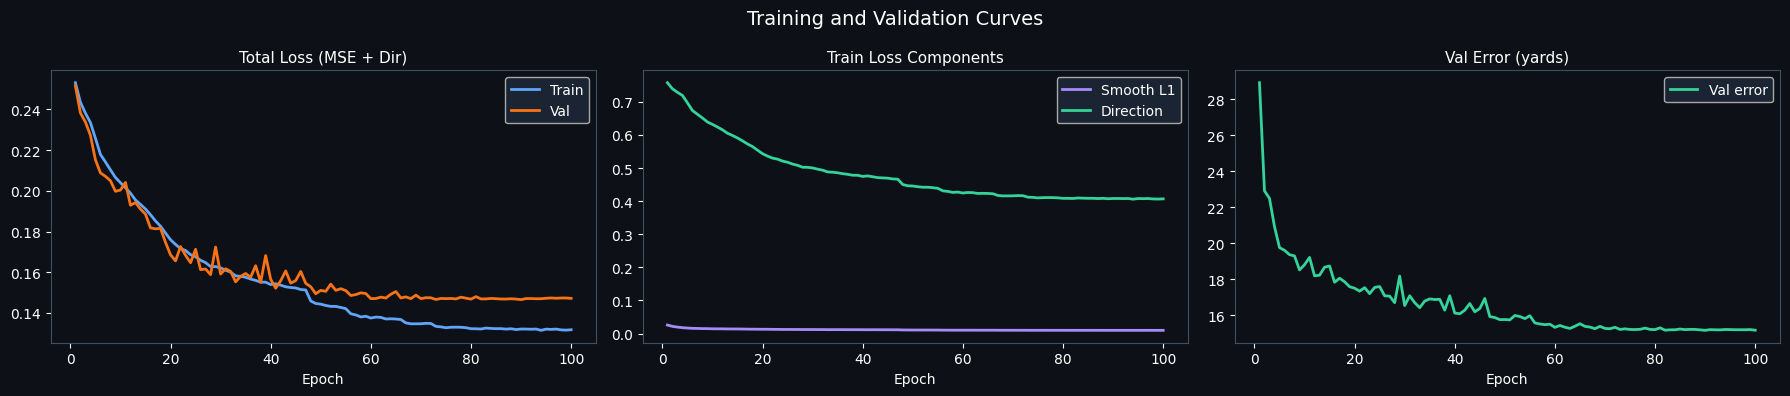

In [9]:
from src.analysis.plots import plot_training_curves
import matplotlib.pyplot as plt

fig = plot_training_curves(history)
plt.show()

## 8. Evaluate on Test Set

Val set size:     15300
Mean error:       15.32 yards
Median error:     12.72 yards
90th percentile:  29.48 yards
Within  5 yards:  11.5%
Within 10 yards:  36.9%
Within 20 yards:  74.9%


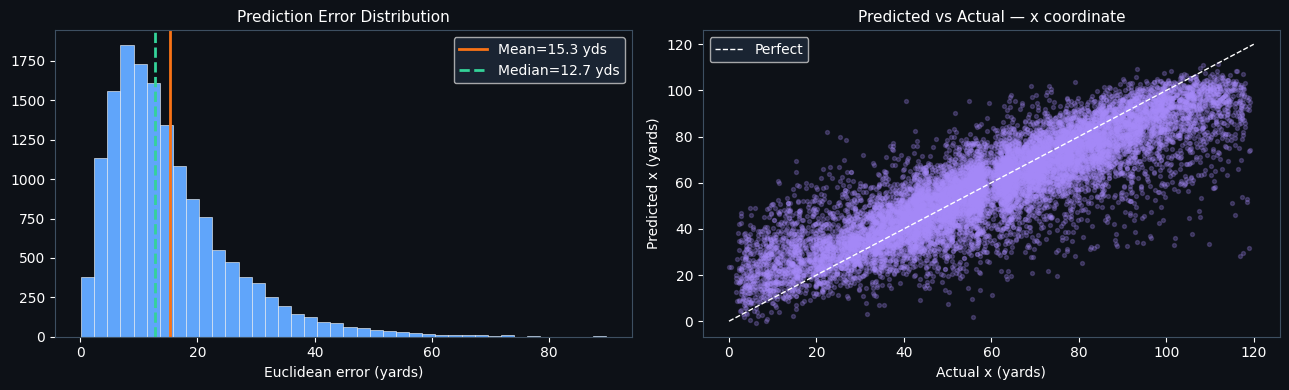

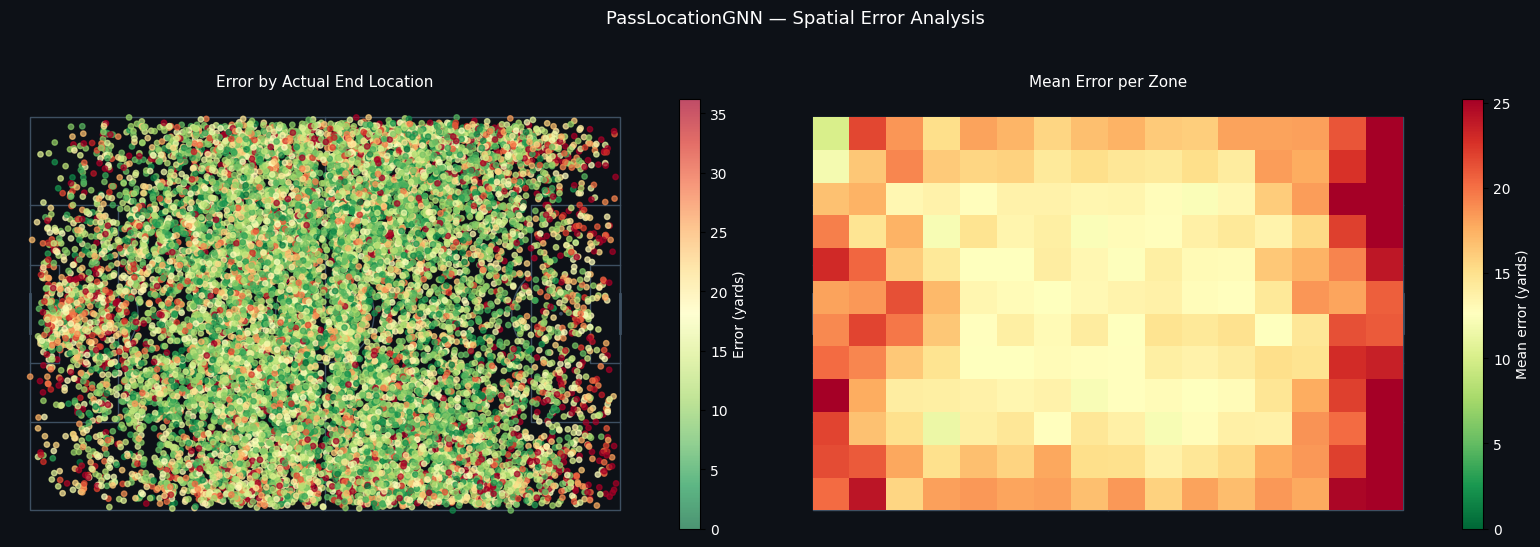

In [10]:
from src.analysis.errors import evaluate, print_summary, zone_breakdown, distance_breakdown
from src.analysis.plots import plot_error_distribution, plot_spatial_error, plot_zone_breakdown, plot_distance_breakdown

results = evaluate(model, test_loader, player_vocab, device=DEVICE)
print_summary(results['errors'])

fig = plot_error_distribution(results['errors'], results['targets'], results['preds'])
plt.show()

fig = plot_spatial_error(results['errors'], results['targets'])
plt.show()

                  mean  median  count
zone                                 
Defensive third  16.52   13.76   3787
Middle third     15.10   12.30   8341
Attacking third  14.43   12.43   3172


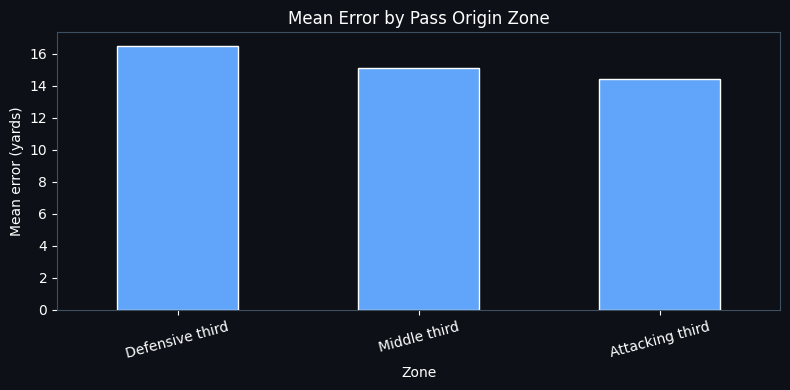

                      mean     median  count
distance                                    
Short (<15 yds)  10.870000   9.870000   6841
Medium (15-40)   16.870001  15.250000   7725
Long (>40)       40.360001  39.610001    734


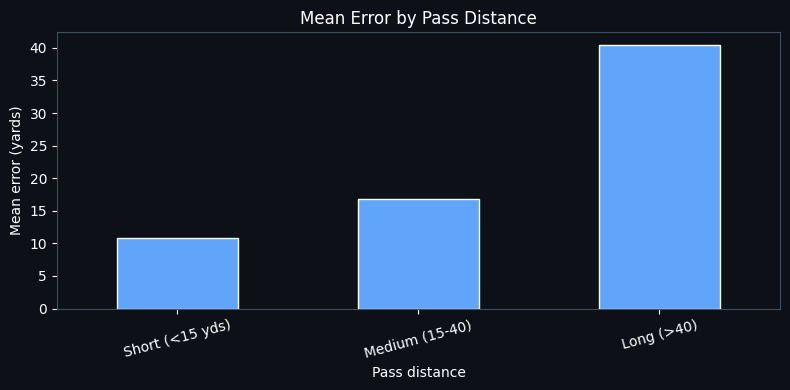

In [11]:
zone_df = zone_breakdown(results['errors'], results['passer_positions'])
print(zone_df.round(2).to_string())
plot_zone_breakdown(zone_df)
plt.show()

dist_df = distance_breakdown(results['errors'], results['passer_positions'], results['targets'])
print(dist_df.round(2).to_string())
plot_distance_breakdown(dist_df)
plt.show()

## 9. Best & Worst Predictions

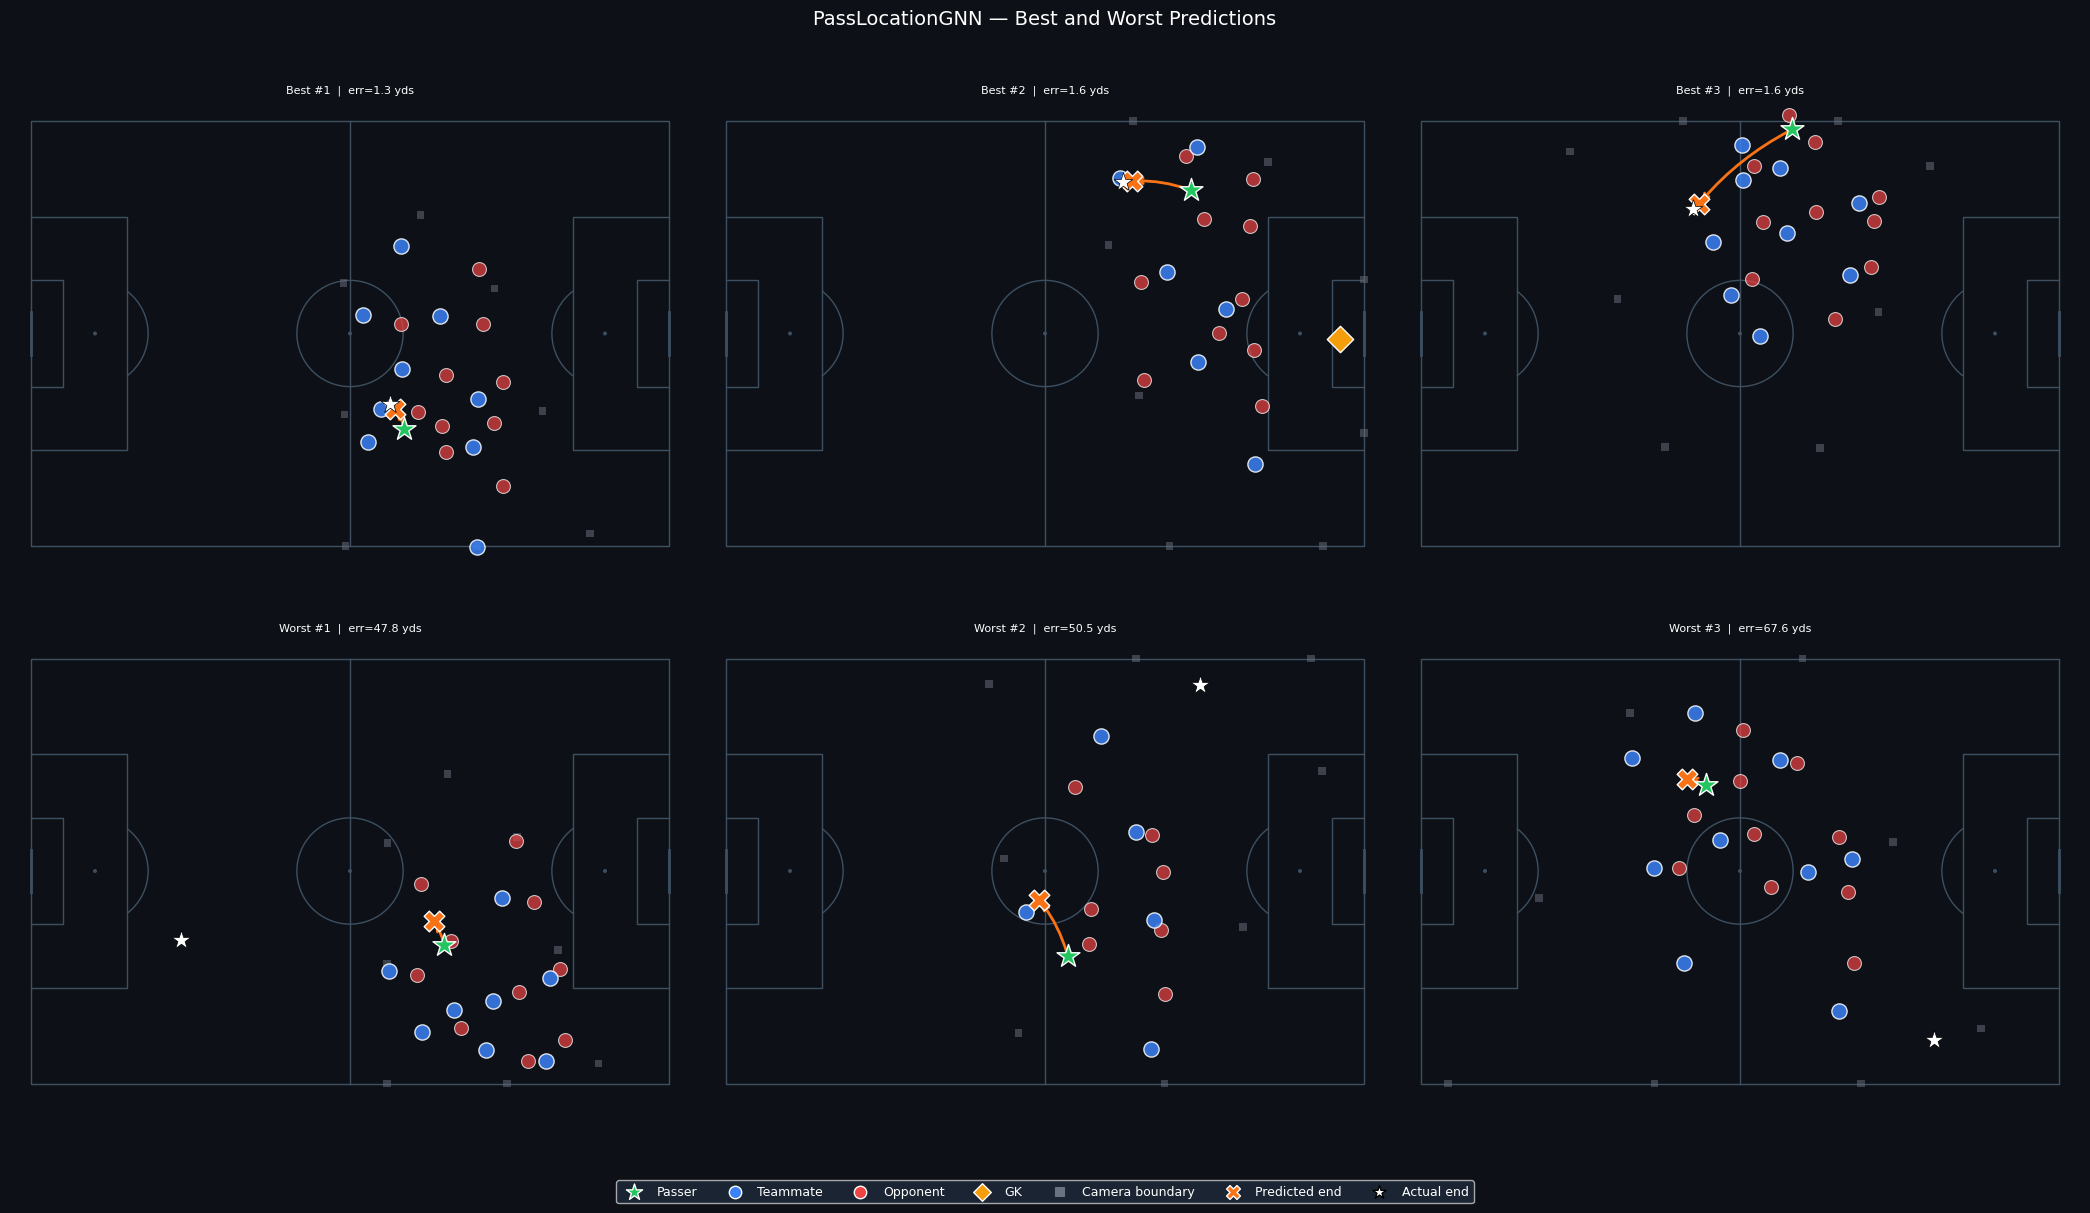

In [12]:
from src.analysis.plots import plot_best_worst_predictions

fig = plot_best_worst_predictions(val_set, model, n=3)
plt.show()

## 10. Save Checkpoint

In [13]:
from src.utils.checkpoint import save

save(model, player_vocab, val_error_yards=history.best_val_error)

Saved checkpoint -> pass_location_gnn_v9.pt  (val_err=15.17 yds)


In [14]:
from src.utils.checkpoint import load
from config import CHECKPOINT_PATH

model, player_vocab, ckpt = load(CHECKPOINT_PATH)

Loaded checkpoint from pass_location_gnn_v9.pt  (val_err=15.17 yds)


## 11. Player Inference — Counterfactual Swapping

True end location: [94.9 18.6]

  player=Ismaïla Sarr (Left Wing)  ->  (102.4, 20.8) yds
  player=Youri Tielemans (Right Defensive Midfield)  ->  (94.7, 19.4) yds
  player=Marcus Thuram (Left Wing)  ->  (95.5, 18.7) yds


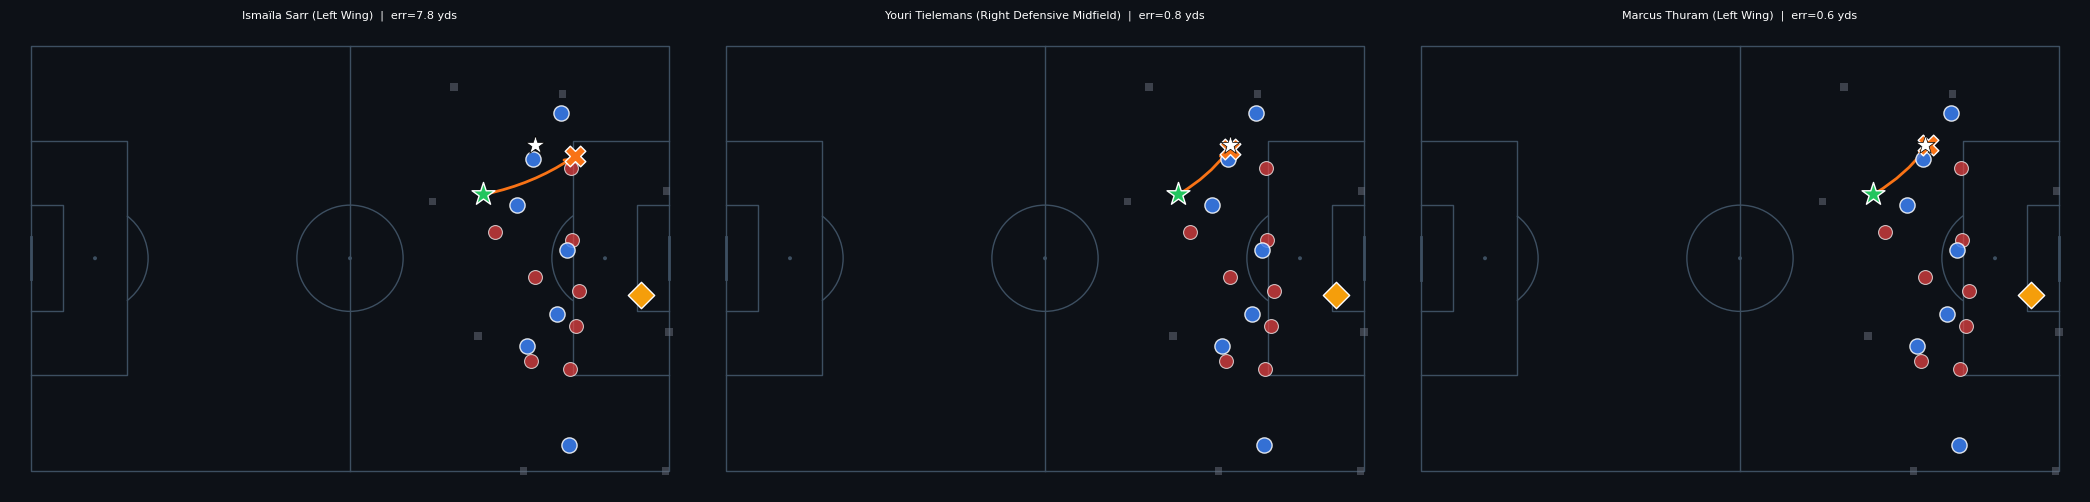

In [52]:
from src.analysis.plots import plot_prediction_with_player

sample_graph = test_set[4]
sample_pids = list(player_vocab.keys())[:3]

plot_prediction_with_player(sample_graph, sample_pids, model, player_vocab, pid_to_label)

## 12. Player Similarity — Section 16: Actual Pass Profiles

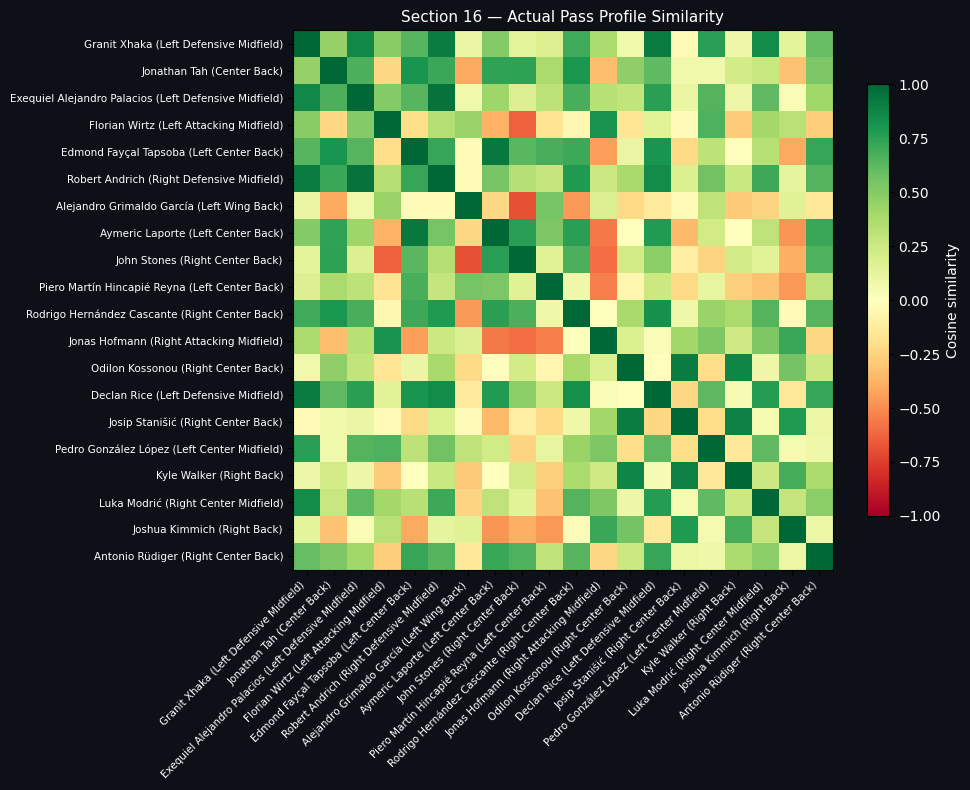

In [ ]:
from src.analysis.player_similarity import compute_pass_profiles, cosine_similarity_matrix
from src.analysis.plots import plot_similarity_heatmap

profile_df = compute_pass_profiles(pass_events)
profile_ids = profile_df.index.tolist()
profile_labels = [pid_to_label.get(p, str(p)) for p in profile_ids]
profile_cos = cosine_similarity_matrix(profile_df)

import pandas as pd
pass_counts = pass_events['player_id'].value_counts()
top20_pids = [p for p in pass_counts.index if p in profile_df.index][:20]
top20_idx = [profile_ids.index(p) for p in top20_pids]
top20_labels = [profile_labels[i] for i in top20_idx]
sub = profile_cos[np.ix_(top20_idx, top20_idx)]

fig = plot_similarity_heatmap(sub, top20_labels, 'Section 16 — Actual Pass Profile Similarity')
plt.show()

## 13. Player Similarity

In [17]:
from src.analysis.player_similarity import (
    build_style_sample, run_cross_prediction, compute_predicted_profiles
)

style_sample = build_style_sample(test_set)
cross_buckets = run_cross_prediction(style_sample, model, player_vocab)
pred_centroids, pred_profile_df = compute_predicted_profiles(cross_buckets)

pred_profile_ids = pred_profile_df.index.tolist()
pred_profile_labels = [pid_to_label.get(p, str(p)) for p in pred_profile_ids]
pred_cos = cosine_similarity_matrix(pred_profile_df)

print(f'Players in predicted profile: {len(pred_profile_df)}')
print(pred_centroids.head(8).round(1).to_string())

Style sample: 198 graphs across 9 strata
  Def / Drawing: 2028 avail -> 22 sampled
  Def / Winning: 858 avail -> 22 sampled
  Def / Losing: 883 avail -> 22 sampled
  Mid / Drawing: 4431 avail -> 22 sampled
  Mid / Winning: 1970 avail -> 22 sampled
  Mid / Losing: 1945 avail -> 22 sampled
  Att / Drawing: 1634 avail -> 22 sampled
  Att / Winning: 755 avail -> 22 sampled
  Att / Losing: 796 avail -> 22 sampled


Cross-predicting: 100%|██████████| 198/198 [00:56<00:00,  3.50it/s]


Players in predicted profile: 1495
           mean_pred_x  mean_pred_y  n_passes
player_id                                    
2941              56.3         41.6       198
2954              61.8         40.6       198
2972              61.8         41.3       198
2988              57.6         43.9       198
2989              62.4         44.4       198
2995              58.2         36.8       198
2999              60.9         40.8       198
3009              57.8         43.4       198


## 14. Player Similarity

Compares raw 2D point clouds directly — no feature engineering.

| Method | Sensitive to | Units |
|--------|-------------|-------|
| Energy Distance | Location differences | yards |
| MMD (RBF) | Location + shape/spread | dimensionless |

In [19]:
from src.analysis.player_similarity import (
    compute_emd_matrix, compute_mmd_matrix, dissim_to_sim,
    extract_point_clouds, most_divergent_pair, cross_method_correlation,
    nearest_players,
)
from src.analysis.plots import (
    plot_four_method_comparison, plot_distinctiveness_bar,
    plot_centroid_scatter, plot_kde_comparison, print_cross_method_correlation,
)

point_clouds = extract_point_clouds(cross_buckets)

emd_mat,  cloud_pids = compute_emd_matrix(point_clouds)
mmd_mat, _,  sigma2 = compute_mmd_matrix(point_clouds)
cloud_labels = [pid_to_label.get(p, str(p)) for p in cloud_pids]

emd_sim  = dissim_to_sim(emd_mat)
mmd_sim = dissim_to_sim(mmd_mat)

print(f'Earth Mover Distance  min={emd_mat[emd_mat>0].min():.2f} yds  '
      f'max={emd_mat.max():.2f} yds  mean={emd_mat[emd_mat>0].mean():.2f} yds')
print(f'MMD²             min={mmd_mat[mmd_mat>0].min():.4f}  '
      f'max={mmd_mat.max():.4f}  mean={mmd_mat[mmd_mat>0].mean():.4f}')

Earth Mover Distance: 100%|██████████| 1116765/1116765 [1:16:04<00:00, 244.68it/s]


MMD bandwidth σ² = 1594.75 (median heuristic)


MMD: 100%|██████████| 1116765/1116765 [46:39<00:00, 398.85it/s]


Earth Mover Distance  min=1.52 yds  max=29.77 yds  mean=8.03 yds
MMD²             min=0.0000  max=0.2083  mean=0.0140


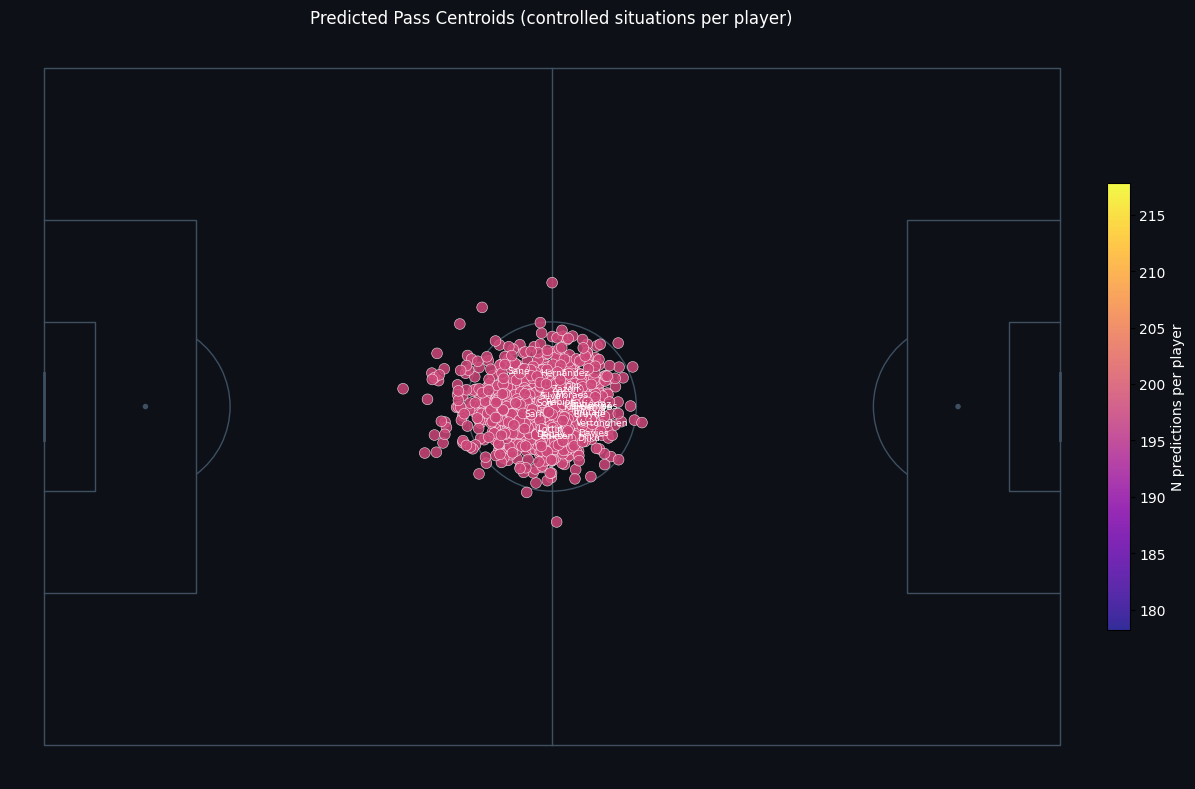

Nearest centroids to Ismaïla Sarr (Left Wing):
    0.1 yds  Semih Kılıçsoy (Center Attacking Midfield)
    0.1 yds  Romelu Lukaku Menama (Center Forward)
    0.1 yds  Mikel Oyarzabal Ugarte (Right Wing)
    0.2 yds  Aziz Eraltay Behich (Left Back)
    0.3 yds  Stefan Lainer (Right Back)


In [20]:
# Centroid scatter — all players on pitch
fig = plot_centroid_scatter(pred_centroids, pid_to_label)
plt.show()

# Nearest-centroid lookup for the most active player
top_pid = pred_centroids['n_passes'].idxmax()
nearest_players(top_pid, pred_centroids, pid_to_label, n=5)

Most divergent pair: Bailey Wright (Right Center Back)  vs  Abolfazl Jalali (Left Back)


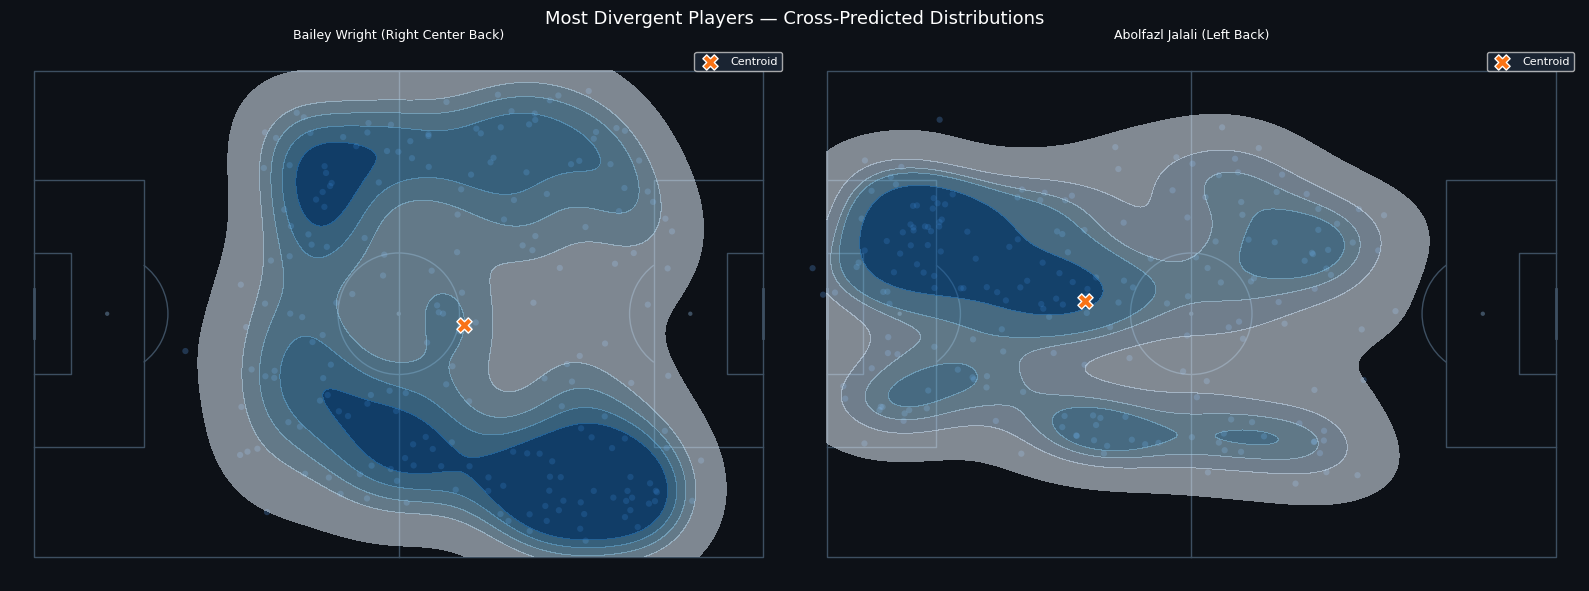

In [21]:
# KDE pitch plots for the two most stylistically divergent players
p1, p2 = most_divergent_pair(point_clouds, pred_centroids)
print(f'Most divergent pair: {pid_to_label.get(p1, p1)}  vs  {pid_to_label.get(p2, p2)}')

fig = plot_kde_comparison(cross_buckets, pred_centroids, pid_to_label, p1, p2)
plt.show()

## 15. Player Similarity — Name Lookup

`find_similar_players(name, ...)` resolves a partial or full player name
(case-insensitive) and returns their top-N most similar players ranked
across all four similarity methods simultaneously.

All four similarity sources are optional — pass whichever you have computed.
Players missing from a given method get a `—` in that column but are still
ranked on the methods where they do appear.

In [ ]:
from src.analysis.player_similarity import find_similar_players

# ── Change this to any player name in your dataset ────────────────────────────
QUERY_NAME = "Messi"   # partial names work: "messi", "de jong", "pedri"

results_df = find_similar_players(
    QUERY_NAME,
    pid_to_label,
    n=10,
    # S16 — actual pass profile cosine similarity
    profile_ids=profile_ids,
    profile_cos=profile_cos,
    # S18 — direct distribution comparison
    cloud_pids=cloud_pids,
    ed_mat=emd_mat,
    mmd_mat=mmd_mat,
)


Top 10 most similar players to: Lionel Andrés Messi Cuccittini (Right Center Forward)
──────────────────────────────────────────────────────────────────────────────────────────────────────
Rank  Player                                      S16 cosine    S17 cosine      ED (yds)          MMD²
──────────────────────────────────────────────────────────────────────────────────────────────────────
   1  Antoine Griezmann (Center Attacking Midfield)        0.9106        0.6589          5.6y       0.00000
   2  Ruslan Malinovskiy (Left Wing)                  0.7913        0.8018          5.6y       0.00030
   3  Aleksandr Golovin (Left Attacking Midfield)        0.6460        0.8051          5.0y       0.00000
   4  Mohammed Kudus (Left Center Midfield)           0.9301        0.3635          4.7y       0.00000
   5  Weston McKennie (Right Center Midfield)         0.8070        0.4581          5.4y       0.00000
   6  Václav Černý (Right Attacking Midfield)         0.5845        0.9044       